# 🧠🤖 Treinando uma CNN com Pytorch

1. https://learnopencv.com/understanding-convolutional-neural-networks-cnn/
1. https://medium.com/codex/understanding-convolutional-neural-networks-a-beginners-journey-into-the-architecture-aab30dface10
2. https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
3. https://www.youtube.com/watch?v=KuXjwB4LzSA
4. https://www.youtube.com/watch?app=desktop&v=JboZfxUjLSk
5. https://www.kaggle.com/code/amarjeet007/visualize-cnn-with-keras


Neste notebook, vamos treinar uma rede neural convolucional usando a base de dados MNIST. Seguiremos os seguintes passos em ordem:

1. Carregar e normalizar os conjuntos de dados de treinamento e teste usando `torchvision`
2. Definir uma Rede Neural Convolucional
3. Definir uma função de perda
4. Treinar a rede com os dados de treinamento
5. Testar a rede com os dados de teste

**Obs.**: O pacote `torchvision` possui várias classes úteis para operação com imagens. 


## Exemplo Simples de Convolução com Imagens

In [66]:
import cv2
import numpy as np

def convolve(img, kernel):
    # cria a imagem de saida
    out = np.zeros_like(img)

    # Cria uma copia da entrada com padding.
    # Assume kernel de tamanho impar e quadrado
    pad_sz = (kernel.shape[0] // 2)
    padded = np.zeros((img.shape[0] + 2 * pad_sz, img.shape[1] + 2 * pad_sz))
    padded[pad_sz: img.shape[0] + pad_sz, pad_sz: img.shape[1] + pad_sz] = img

    # itera sobre os pixels da imagem
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            # seleciona a subimagem
            subimg = padded[i:i + kernel.shape[0], j:j + kernel.shape[1]]

            # multiplica o kernel pela subimagem elemento a elemento
            # e soma os valores
            out[i, j] = np.sum(kernel * subimg)

    return out



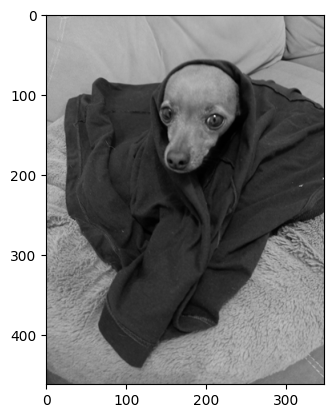

In [67]:
import matplotlib.pyplot as plt

img = cv2.cvtColor(cv2.imread("magui.png"), cv2.COLOR_BGR2GRAY)
img = img.astype(float) / 255
plt.imshow(img, cmap='gray')

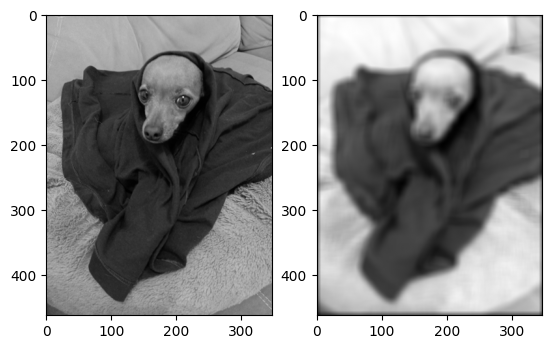

In [68]:
kernel = np.ones((13, 13))
kernel /= kernel.size

out = convolve(img, kernel)
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(out, cmap='gray')

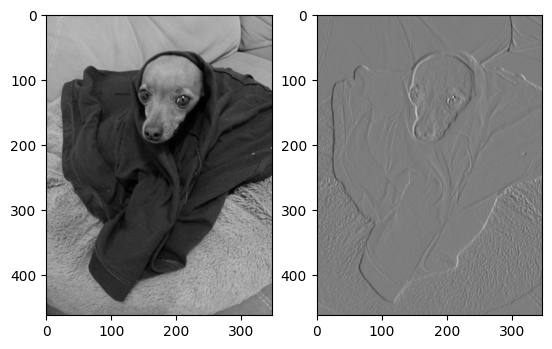

In [69]:
kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
])

out = convolve(img, kernel)
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(out, cmap='gray')

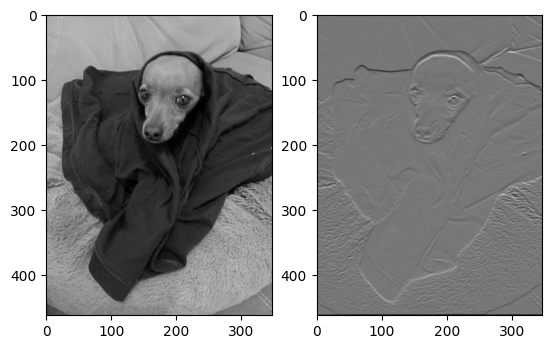

In [70]:
kernel = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1],
])

out = convolve(img, kernel)
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(out, cmap='gray')

## Treinamento de uma CNN com Pytorch


### Carrega e normaliza os dados


In [71]:
import torch
import torchvision
import torchvision.transforms as transforms

In [72]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     # normaliza para [-1, 1] subtraindo 0.5 e depois dividindo poir 0.5
     transforms.Normalize((0.5), (0.5))])

batch_size = 64

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = [str(i) for i in range(10)]

Visualização de algumas imagens de treino


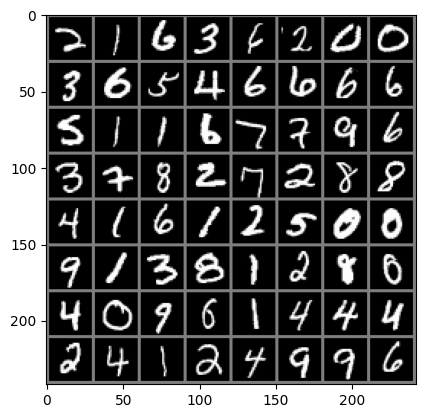

2     1     6     3     6     2     0     0     3     6     5     4     6     6     6     6     5     1     1     6     7     7     9     6     3     7     8     2     7     2     8     8     4     1     6     1     2     5     0     0     9     1     3     8     1     2     8     0     4     0     9     6     1     4     4     4     2     4     1     2     4     9     9     6    


In [73]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

### 2. Define a CNN



In [74]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # para saber o tamanho da entrada abaixo, faça um print do x no forward antes do flatten
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()


Forma alternativa de definir a CNN usando nn.Sequential:

In [110]:

net = nn.Sequential(
    nn.Conv2d(1, 6, 5),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(6, 16, 5),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Flatten(),   # lembre-se do flatten!
    nn.Linear(16 * 4 * 4, 120),
    nn.ReLU(),
    nn.Linear(120, 84),
    nn.ReLU(),
    nn.Linear(84, 10)
)

### Define a Loss function e o optimizer


In [111]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=1e-2)

### Treina a Rede


In [112]:

for epoch in range(2):  # loop over the dataset multiple times
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()

    print(f'[{epoch + 1}] loss: {running_loss:.3f}')
    running_loss = 0.0

print('Finished Training')

[1] loss: 165.075
[2] loss: 87.669
Finished Training


A próxima célula salva o modelo.
Clique [aqui](https://pytorch.org/docs/stable/notes/serialization.html) para saber mais sobre como salvar e carregar PyTorch models.

In [113]:
PATH = './cnn-mnist.pth'
torch.save(net, PATH)



### Test the network on the test data



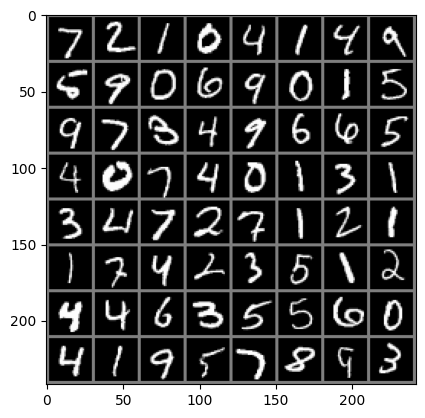

GroundTruth:  7     2     1     0     4     1     4     9     5     9     0     6     9     0     1     5     9     7     3     4     9     6     6     5     4     0     7     4     0     1     3     1     3     4     7     2     7     1     2     1     1     7     4     2     3     5     1     2     4     4     6     3     5     5     6     0     4     1     9     5     7     8     9     3    


In [101]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(images.shape[0])))

Next, let\'s load back in our saved model (note: saving and re-loading
the model wasn\'t necessary here, we only did it to illustrate how to do
so):


In [116]:
net = torch.load(PATH, weights_only=False)

Okay, now let us see what the neural network thinks these examples above
are:


In [105]:
outputs = net(images)
_, predicted = torch.max(outputs, 1)
print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(images.shape[0])))

Predicted:  6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6    


Resultados no conjunto de teste:

In [117]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on test images: {100 * correct // total} %')

Accuracy of the network on test images: 98 %


In [ ]:
del dataiter